# 03 — Census tracts and ACS

San Diego County (**06073**) tracts: TIGER/Line geometry + ACS 5-year (`scripts/download_data.py` JSON). **Paper-oriented check:** whether **relative MOE** (MOE / estimate) rises where **disadvantage** proxies are high — motivation for hierarchical / partial pooling.

**Naming:** `artifacts/tables/eda__<desc>__<YYYY-MM-DD>.csv`, `artifacts/figures/eda__<desc>__<YYYY-MM-DD>.png` (dpi=200).

**Prior:** [`02_gtfs_schedule_exploration.ipynb`](02_gtfs_schedule_exploration.ipynb)  
**Next:** [`04_spatial_alignment_and_coverage.ipynb`](04_spatial_alignment_and_coverage.ipynb)


In [1]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import Markdown, display
from scipy import stats

warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")


def find_repo_root() -> Path:
    start = Path.cwd().resolve()
    for d in [start, *start.parents]:
        if (d / "configs" / "san_diego.yaml").exists():
            return d
    raise FileNotFoundError("Could not find configs/san_diego.yaml (cd to repo root).")


REPO_ROOT = find_repo_root()

with open(REPO_ROOT / "configs" / "defaults.yaml") as f:
    config = yaml.safe_load(f)
with open(REPO_ROOT / "configs" / "san_diego.yaml") as f:
    config.update(yaml.safe_load(f))

state_fips = str(config["state_fips"]).zfill(2)
county_fips = str(config["county_fips"]).zfill(3)
census_cfg = config.get("census", {})
acs_year = int(census_cfg.get("acs_year", 2023))
bbox = config.get("bbox")

print(f"Study area: state {state_fips}, county {county_fips}, ACS {acs_year}")


Study area: state 06, county 073, ACS 2023


## Load ACS tract table (JSON)

Variables match `download_data.py` Census API pull. `GEOID` = state + county + tract (11 digits).


In [2]:
acs_path = (
    REPO_ROOT / "data" / "raw" / "census" / f"acs5_{acs_year}_sd_county.json"
)
with open(acs_path, encoding="utf-8") as f:
    raw = json.load(f)

header, *data_rows = raw
acs = pd.DataFrame(data_rows, columns=header)

num_cols = [
    "B01003_001E",
    "B01003_001M",
    "B08201_002E",
    "B08201_002M",
    "B19013_001E",
    "B19013_001M",
    "B17001_002E",
    "B17001_002M",
    "B18101_001E",
    "B18101_001M",
    "B03002_001E",
    "B03002_003E",
    "B03002_012E",
    "B03002_004E",
]
for c in num_cols:
    acs[c] = pd.to_numeric(acs[c], errors="coerce")

# Census missing-value sentinels for income
for c in ("B19013_001E", "B19013_001M"):
    acs.loc[acs[c] < 0, c] = np.nan

acs["GEOID"] = (
    acs["state"].astype(str).str.zfill(2)
    + acs["county"].astype(str).str.zfill(3)
    + acs["tract"].astype(str).str.zfill(6)
)

# Approximate rates (denominator = total population where noted — document in methods)
pop = acs["B01003_001E"].replace(0, np.nan)
acs["poverty_rate"] = acs["B17001_002E"] / pop
acs["no_vehicle_hh_rate"] = acs["B08201_002E"] / pop
acs["pct_nh_white"] = acs["B03002_003E"] / acs["B03002_001E"].replace(0, np.nan)
acs["pct_hispanic"] = acs["B03002_012E"] / acs["B03002_001E"].replace(0, np.nan)
acs["pct_black"] = acs["B03002_004E"] / acs["B03002_001E"].replace(0, np.nan)

# Relative MOE (coefficient-like uncertainty)
acs["rel_moe_pop"] = acs["B01003_001M"] / pop
acs["rel_moe_poverty_count"] = acs["B17001_002M"] / acs["B17001_002E"].replace(0, np.nan)
acs["rel_moe_no_vehicle"] = acs["B08201_002M"] / acs["B08201_002E"].replace(0, np.nan)

# Simple disadvantage composite (z-scores; higher = more disadvantaged)


def zscore(s: pd.Series) -> pd.Series:
    s = pd.to_numeric(s, errors="coerce")
    sd = s.std(ddof=1)
    if sd == 0 or pd.isna(sd):
        return pd.Series(0.0, index=s.index)
    return (s - s.median()) / sd


pr = acs["poverty_rate"]
nv = acs["no_vehicle_hh_rate"]
inc = acs["B19013_001E"]
acs["disadvantage_z"] = (
    zscore(pr.fillna(pr.median()))
    + zscore(nv.fillna(nv.median()))
    + zscore((-inc).fillna((-inc).median()))
) / 3.0

display(Markdown(f"**ACS tracts loaded:** {len(acs)} from `{acs_path.relative_to(REPO_ROOT)}`"))
acs[["GEOID", "NAME", "B01003_001E", "poverty_rate", "rel_moe_pop", "disadvantage_z"]].head()


**ACS tracts loaded:** 737 from `data\raw\census\acs5_2023_sd_county.json`

,GEOID,NAME,B01003_001E,poverty_rate,rel_moe_pop,disadvantage_z
0,06073000100,Census Tract 1; San Diego County; California,2746,0.016752,0.125273,-1.217822
1,06073000201,Census Tract 2.01; San Diego County; California,2376,0.088384,0.146044,0.681944
2,06073000202,Census Tract 2.02; San Diego County; California,4019,0.039313,0.099278,-0.182962
3,06073000301,Census Tract 3.01; San Diego County; California,2487,0.155207,0.171693,1.006753
4,06073000302,Census Tract 3.02; San Diego County; California,2925,0.094701,0.109744,0.364107


## TIGER tracts (California → San Diego County)


In [3]:
import geopandas as gpd

tiger_dir = REPO_ROOT / "data" / "raw" / "census" / f"tl_{acs_year}_{state_fips}_tract"
shp = tiger_dir / f"tl_{acs_year}_{state_fips}_tract.shp"
if not shp.exists():
    raise FileNotFoundError(f"Missing shapefile: {shp}")

tracts_all = gpd.read_file(shp)
tracts_sd = tracts_all[tracts_all["COUNTYFP"].astype(str).str.zfill(3) == county_fips].copy()
tracts_sd = tracts_sd.to_crs(4326)

display(
    Markdown(
        f"**TIGER:** {len(tracts_sd)} tracts in county {state_fips}{county_fips} "
        f"(from {len(tracts_all)} CA tracts)"
    )
)

# Merge ACS attributes onto geometries
merged = tracts_sd.merge(acs, on="GEOID", how="left", suffixes=("_tiger", ""))
n_miss = merged["B01003_001E"].isna().sum()
if n_miss:
    display(Markdown(f"_Warning: {n_miss} tracts without ACS match on GEOID_"))

tracts_sd.head(2)


**TIGER:** 737 tracts in county 06073 (from 9129 CA tracts)

,STATEFP,COUNTYFP,TRACTCE,GEOID,GEOIDFQ,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
810,06,073,008331,06073008331,1400000US06073008331,83.31,Census Tract 83.31,G5020,S,954207,0,+32.9426037,-117.2241058,"POLYGON ((-117.23082 32.94176, -117.23079 32.9..."
819,06,073,008336,06073008336,1400000US06073008336,83.36,Census Tract 83.36,G5020,S,828562,0,+32.9678415,-117.1331584,"POLYGON ((-117.13793 32.96927, -117.13792 32.9..."


## MOE vs disadvantage (Spearman)


In [4]:
pairs = [
    ("poverty_rate", "rel_moe_pop", "Pop estimate relative MOE"),
    ("poverty_rate", "rel_moe_poverty_count", "Poverty count relative MOE"),
    ("disadvantage_z", "rel_moe_pop", "Disadvantage z vs pop rel MOE"),
    ("disadvantage_z", "rel_moe_poverty_count", "Disadvantage z vs poverty rel MOE"),
    ("no_vehicle_hh_rate", "rel_moe_pop", "No-vehicle rate vs pop rel MOE"),
    ("pct_black", "rel_moe_pop", "Pct Black vs pop rel MOE"),
    ("pct_hispanic", "rel_moe_pop", "Pct Hispanic vs pop rel MOE"),
]

corr_rows = []
sub = merged.dropna(subset=["rel_moe_pop"]).copy()
for x, y, label in pairs:
    a = pd.to_numeric(sub[x], errors="coerce")
    b = pd.to_numeric(sub[y], errors="coerce")
    m = a.notna() & b.notna() & np.isfinite(a) & np.isfinite(b)
    if m.sum() < 10:
        rho, p = np.nan, np.nan
    else:
        rho, p = stats.spearmanr(a[m], b[m])
    corr_rows.append(
        {"comparison": label, "x": x, "y": y, "n": int(m.sum()), "spearman_rho": rho, "p_value": p}
    )

corr_df = pd.DataFrame(corr_rows)
display(corr_df)

# Interpretation helper
strong = corr_df[(corr_df["p_value"] < 0.05) & (corr_df["spearman_rho"].abs() > 0.15)]
if not strong.empty:
    display(Markdown("**Statistically notable (p<0.05, |rho|>0.15):**"))
    display(strong)
else:
    display(Markdown("_No pairs passed both thresholds; still report full table in paper supplement._"))


,comparison,x,y,n,spearman_rho,p_value
0,Pop estimate relative MOE,poverty_rate,rel_moe_pop,735,0.161776,1.045757e-05
1,Poverty count relative MOE,poverty_rate,rel_moe_poverty_count,727,-0.530544,5.070845e-54
2,Disadvantage z vs pop rel MOE,disadvantage_z,rel_moe_pop,735,0.157548,1.780207e-05
3,Disadvantage z vs poverty rel MOE,disadvantage_z,rel_moe_poverty_count,727,-0.555834,3.524803e-60
4,No-vehicle rate vs pop rel MOE,no_vehicle_hh_rate,rel_moe_pop,735,0.060663,1.003130e-01
5,Pct Black vs pop rel MOE,pct_black,rel_moe_pop,735,0.042011,2.553160e-01
6,Pct Hispanic vs pop rel MOE,pct_hispanic,rel_moe_pop,735,0.198926,5.378618e-08


**Statistically notable (p<0.05, |rho|>0.15):**

,comparison,x,y,n,spearman_rho,p_value
0,Pop estimate relative MOE,poverty_rate,rel_moe_pop,735,0.161776,1.045757e-05
1,Poverty count relative MOE,poverty_rate,rel_moe_poverty_count,727,-0.530544,5.070845e-54
2,Disadvantage z vs pop rel MOE,disadvantage_z,rel_moe_pop,735,0.157548,1.780207e-05
3,Disadvantage z vs poverty rel MOE,disadvantage_z,rel_moe_poverty_count,727,-0.555834,3.524803e-60
6,Pct Hispanic vs pop rel MOE,pct_hispanic,rel_moe_pop,735,0.198926,5.378618e-08


## Figures


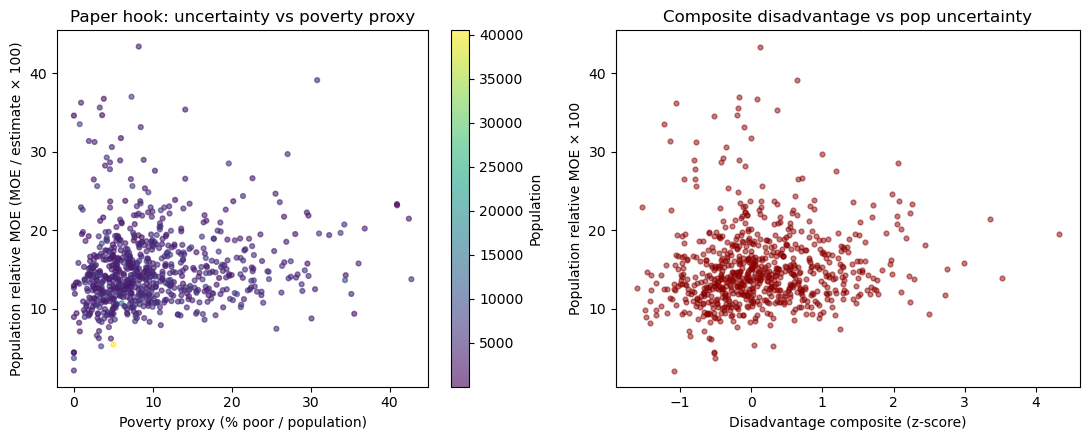

Saved: artifacts\figures\eda__acs_moe_vs_disadvantage__2026-03-29.png


In [5]:
ART_FIG = REPO_ROOT / "artifacts" / "figures"
ART_FIG.mkdir(parents=True, exist_ok=True)
from datetime import date as _date

TODAY = _date.today().isoformat()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sub = merged.dropna(subset=["poverty_rate", "rel_moe_pop", "B01003_001E"]).copy()
sub = sub[np.isfinite(sub["poverty_rate"]) & np.isfinite(sub["rel_moe_pop"])]
ax = axes[0]
sc = ax.scatter(
    sub["poverty_rate"] * 100,
    sub["rel_moe_pop"] * 100,
    c=sub["B01003_001E"],
    cmap="viridis",
    alpha=0.6,
    s=12,
)
plt.colorbar(sc, ax=ax, label="Population")
ax.set_xlabel("Poverty proxy (% poor / population)")
ax.set_ylabel("Population relative MOE (MOE / estimate × 100)")
ax.set_title("Paper hook: uncertainty vs poverty proxy")

ax = axes[1]
sub2 = merged.dropna(subset=["disadvantage_z", "rel_moe_pop"]).copy()
sub2 = sub2[np.isfinite(sub2["disadvantage_z"]) & np.isfinite(sub2["rel_moe_pop"])]
ax.scatter(sub2["disadvantage_z"], sub2["rel_moe_pop"] * 100, alpha=0.5, s=12, c="darkred")
ax.set_xlabel("Disadvantage composite (z-score)")
ax.set_ylabel("Population relative MOE × 100")
ax.set_title("Composite disadvantage vs pop uncertainty")

plt.tight_layout()
p1 = ART_FIG / f"eda__acs_moe_vs_disadvantage__{TODAY}.png"
fig.savefig(p1, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {p1.relative_to(REPO_ROOT)}")


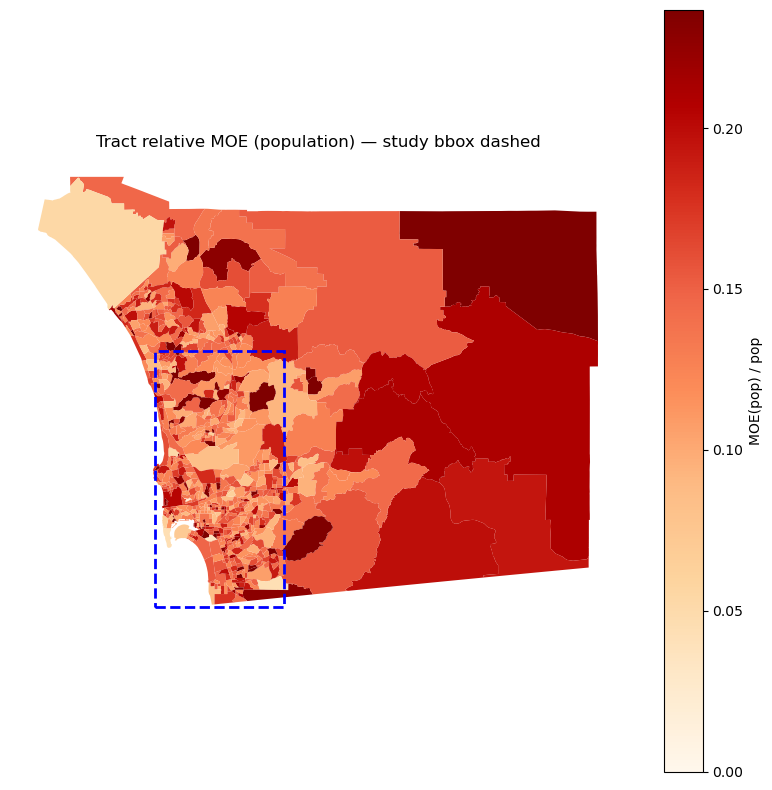

Saved: artifacts\figures\eda__acs_choropleth_rel_moe_pop__2026-03-29.png


In [6]:
# Choropleth: relative MOE of population
fig, ax = plt.subplots(figsize=(8, 8))
plot_df = merged[merged["rel_moe_pop"].notna()].copy()
plot_df = plot_df[np.isfinite(plot_df["rel_moe_pop"])]
plot_df.plot(
    column="rel_moe_pop",
    cmap="OrRd",
    legend=True,
    ax=ax,
    legend_kwds={"label": "MOE(pop) / pop"},
    vmin=0,
    vmax=np.nanpercentile(plot_df["rel_moe_pop"], 95),
)
if bbox:
    min_lon, min_lat, max_lon, max_lat = bbox
    from matplotlib.patches import Rectangle

    rect = Rectangle(
        (min_lon, min_lat),
        max_lon - min_lon,
        max_lat - min_lat,
        fill=False,
        edgecolor="blue",
        linewidth=2,
        linestyle="--",
    )
    ax.add_patch(rect)
ax.set_title("Tract relative MOE (population) — study bbox dashed")
ax.set_axis_off()
plt.tight_layout()
p2 = ART_FIG / f"eda__acs_choropleth_rel_moe_pop__{TODAY}.png"
fig.savefig(p2, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {p2.relative_to(REPO_ROOT)}")


## Export artifacts (`artifacts/tables/`)

Same pattern as EDA 01/02: `eda__<description>__<YYYY-MM-DD>.csv`


In [7]:
from datetime import date as _date

TODAY = _date.today().isoformat()
ART_TABLES = REPO_ROOT / "artifacts" / "tables"
ART_TABLES.mkdir(parents=True, exist_ok=True)
exported = []

# Tract-level attributes (no geometry)
drop_geom = merged.drop(columns=["geometry"], errors="ignore")
cols_keep = [
    "GEOID",
    "NAME",
    "B01003_001E",
    "B01003_001M",
    "B08201_002E",
    "B08201_002M",
    "B19013_001E",
    "B19013_001M",
    "B17001_002E",
    "B17001_002M",
    "B03002_001E",
    "B03002_003E",
    "B03002_012E",
    "B03002_004E",
    "poverty_rate",
    "no_vehicle_hh_rate",
    "pct_nh_white",
    "pct_hispanic",
    "pct_black",
    "rel_moe_pop",
    "rel_moe_poverty_count",
    "rel_moe_no_vehicle",
    "disadvantage_z",
]
cols_keep = [c for c in cols_keep if c in drop_geom.columns]
p = ART_TABLES / f"eda__acs_sd_tract_attributes__{TODAY}.csv"
drop_geom[cols_keep].to_csv(p, index=False)
exported.append(str(p.relative_to(REPO_ROOT)))

align = pd.DataFrame(
    [
        {"source": "ACS JSON rows", "n": len(acs)},
        {"source": "TIGER SD county tracts", "n": len(tracts_sd)},
        {"source": "Merged (inner would be)", "n": len(merged.dropna(subset=['B01003_001E']))},
    ]
)
p = ART_TABLES / f"eda__acs_tiger_alignment__{TODAY}.csv"
align.to_csv(p, index=False)
exported.append(str(p.relative_to(REPO_ROOT)))

p = ART_TABLES / f"eda__acs_moe_disadvantage_spearman__{TODAY}.csv"
corr_df.to_csv(p, index=False)
exported.append(str(p.relative_to(REPO_ROOT)))

summary = merged[cols_keep].describe().T
p = ART_TABLES / f"eda__acs_summary_stats__{TODAY}.csv"
summary.to_csv(p)
exported.append(str(p.relative_to(REPO_ROOT)))

print("Exported:")
for e in exported:
    print(" ", e)


Exported:
  artifacts\tables\eda__acs_sd_tract_attributes__2026-03-29.csv
  artifacts\tables\eda__acs_tiger_alignment__2026-03-29.csv
  artifacts\tables\eda__acs_moe_disadvantage_spearman__2026-03-29.csv
  artifacts\tables\eda__acs_summary_stats__2026-03-29.csv
